<a href="https://colab.research.google.com/github/MLfinal/Walmart-Recruiting---Store-Sales-Forecasting/blob/dev/models/deep_learning/DLinear/baseline_dlinear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Walmart Sales Forecasting — DLinear baseline

This notebook trains a first DLinear baseline for the Walmart weekly sales task.

Main choices:
- direct 39-week forecast, matching the Kaggle test horizon;
- validation is the last 39 weeks of `train.csv`;
- metric is Kaggle-style weighted MAE, where holiday rows receive weight 5;
- model is a global univariate DLinear trained across all Store-Dept series;
- runs, metrics, plots, predictions, and model checkpoints are logged to W&B;
- no MLflow is used.

In [1]:
%pip install -q "torch>=2.3,<3" "wandb>=0.19,<1" "pandas>=2.2,<3" "numpy>=1.26,<3" "matplotlib>=3.8,<4"

In [2]:
from __future__ import annotations

import json
import math
import os
import platform
import random
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import wandb

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

pd.set_option("display.max_columns", 100)
print({
    "python": platform.python_version(),
    "torch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "device_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
})

{'python': '3.12.13', 'torch': '2.11.0+cpu', 'cuda_available': False, 'device_name': 'cpu'}


## Configuration

`validation_weeks=39` is intentional because the competition test set also spans 39 weekly dates. The model learns to forecast the whole horizon directly instead of recursively predicting one week at a time.

In [3]:
CONFIG = {
    "seed": SEED,
    "validation_weeks": 39,
    "input_weeks": 52,
    "holiday_weight": 5.0,
    "batch_size": 512,
    "epochs": 80,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "patience": 12,
    "num_workers": 2,
    "clip_grad_norm": 1.0,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "run_final_refit": False,
    "wandb_project": "Walmart-Recruiting---Store-Sales-Forecasting",
    "wandb_entity": "kende23-n-a",
    "wandb_group": "dlinear-baseline",
}

DATA_DIR = Path("/content/drive/MyDrive/walmart_competition_data")
OUTPUT_DIR = Path("/content/artifacts/dlinear_baseline")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG

{'seed': 42,
 'validation_weeks': 39,
 'input_weeks': 52,
 'holiday_weight': 5.0,
 'batch_size': 512,
 'epochs': 80,
 'learning_rate': 0.001,
 'weight_decay': 0.0001,
 'patience': 12,
 'num_workers': 2,
 'clip_grad_norm': 1.0,
 'device': 'cpu',
 'run_final_refit': False,
 'wandb_project': 'Walmart-Recruiting---Store-Sales-Forecasting',
 'wandb_entity': 'kende23-n-a',
 'wandb_group': 'dlinear-baseline'}

In [4]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as exc:
    print(f"Not running in Colab or Drive already unavailable: {exc}")

Mounted at /content/drive


## Load data

For the baseline DLinear model I use only the historical target series and the holiday flag for weighting. This keeps the baseline clean: later DLinear experiments can add covariates, embeddings, scaling variants, and other architecture changes.

In [5]:
train_raw = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["Date"])
test_raw = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["Date"])

required_train = {"Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"}
required_test = {"Store", "Dept", "Date", "IsHoliday"}
missing_train = required_train.difference(train_raw.columns)
missing_test = required_test.difference(test_raw.columns)
if missing_train or missing_test:
    raise ValueError({"missing_train": sorted(missing_train), "missing_test": sorted(missing_test)})

train_raw = train_raw.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)
test_raw = test_raw.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

print("train", train_raw.shape, train_raw["Date"].min(), train_raw["Date"].max())
print("test", test_raw.shape, test_raw["Date"].min(), test_raw["Date"].max())
display(train_raw.head())

train (421570, 5) 2010-02-05 00:00:00 2012-10-26 00:00:00
test (115064, 4) 2012-11-02 00:00:00 2013-07-26 00:00:00


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


## Build weekly Store-Dept panel

DLinear expects fixed-length sequences. Walmart data is naturally weekly, but some Store-Dept rows can be missing. The panel below makes every series share the same date columns and fills missing target values with 0. This is a baseline assumption, not a final modeling claim.

In [6]:
all_train_dates = pd.Index(sorted(train_raw["Date"].unique()), name="Date")
test_dates = pd.Index(sorted(test_raw["Date"].unique()), name="Date")

if len(all_train_dates) <= CONFIG["input_weeks"] + CONFIG["validation_weeks"]:
    raise ValueError("Not enough weekly dates for the configured input and validation windows.")

val_dates = all_train_dates[-CONFIG["validation_weeks"]:]
fit_dates = all_train_dates[:-CONFIG["validation_weeks"]]

sales_panel = (
    train_raw.pivot_table(index=["Store", "Dept"], columns="Date", values="Weekly_Sales", aggfunc="sum")
    .reindex(columns=all_train_dates)
    .fillna(0.0)
    .sort_index()
)

holiday_by_date = (
    train_raw[["Date", "IsHoliday"]]
    .drop_duplicates("Date")
    .set_index("Date")
    .reindex(all_train_dates)["IsHoliday"]
    .fillna(False)
    .astype(bool)
)

test_holiday_by_date = (
    test_raw[["Date", "IsHoliday"]]
    .drop_duplicates("Date")
    .set_index("Date")
    .reindex(test_dates)["IsHoliday"]
    .fillna(False)
    .astype(bool)
)

print({
    "n_series": len(sales_panel),
    "n_train_dates": len(all_train_dates),
    "fit_dates": (str(fit_dates.min().date()), str(fit_dates.max().date())),
    "val_dates": (str(val_dates.min().date()), str(val_dates.max().date())),
    "test_horizon": len(test_dates),
})
display(sales_panel.iloc[:5, :5])

{'n_series': 3331, 'n_train_dates': 143, 'fit_dates': ('2010-02-05', '2012-01-27'), 'val_dates': ('2012-02-03', '2012-10-26'), 'test_horizon': 39}


Date        2010-02-05  2010-02-12  2010-02-19  2010-02-26  2010-03-05
Store Dept                                                            
1     1       24924.50    46039.49    41595.55    19403.54    21827.90
      2       50605.27    44682.74    47928.89    44292.87    48397.98
      3       13740.12    10887.84    11523.47    11135.17    12275.58
      4       39954.04    35351.21    36826.95    34660.16    38086.19
      5       32229.38    29620.81    26468.27    24101.89    23082.14

## Metric and datasets

In [7]:
def wmae(y_true: np.ndarray, y_pred: np.ndarray, is_holiday: np.ndarray, holiday_weight: float = 5.0) -> float:
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    weights = np.where(np.asarray(is_holiday, dtype=bool), holiday_weight, 1.0)
    return float(np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights))


class WindowDataset(Dataset):
    def __init__(self, values: np.ndarray, holiday_flags: np.ndarray, input_len: int, pred_len: int, end_pos: int):
        self.values = values.astype(np.float32)
        self.holiday_flags = holiday_flags.astype(bool)
        self.input_len = int(input_len)
        self.pred_len = int(pred_len)
        self.end_pos = int(end_pos)
        self.index = []
        max_start = self.end_pos - self.input_len - self.pred_len
        if max_start < 0:
            raise ValueError("Not enough history to create DLinear windows.")
        n_series = self.values.shape[0]
        for series_idx in range(n_series):
            for start in range(max_start + 1):
                self.index.append((series_idx, start))

    def __len__(self) -> int:
        return len(self.index)

    def __getitem__(self, idx: int):
        series_idx, start = self.index[idx]
        x = self.values[series_idx, start:start + self.input_len]
        y = self.values[series_idx, start + self.input_len:start + self.input_len + self.pred_len]
        mean = x.mean(dtype=np.float64).astype(np.float32)
        std = x.std(dtype=np.float64).astype(np.float32)
        std = np.float32(max(float(std), 1.0))
        x_norm = (x - mean) / std
        y_norm = (y - mean) / std
        target_dates = np.arange(start + self.input_len, start + self.input_len + self.pred_len)
        weights = np.where(self.holiday_flags[target_dates], CONFIG["holiday_weight"], 1.0).astype(np.float32)
        return {
            "x": torch.from_numpy(x_norm[:, None]),
            "y": torch.from_numpy(y_norm),
            "weights": torch.from_numpy(weights),
            "mean": torch.tensor(mean, dtype=torch.float32),
            "std": torch.tensor(std, dtype=torch.float32),
        }


class ValidationDataset(Dataset):
    def __init__(self, values: np.ndarray, holiday_flags: np.ndarray, input_len: int, pred_len: int, split_pos: int):
        self.values = values.astype(np.float32)
        self.holiday_flags = holiday_flags.astype(bool)
        self.input_len = int(input_len)
        self.pred_len = int(pred_len)
        self.split_pos = int(split_pos)

    def __len__(self) -> int:
        return self.values.shape[0]

    def __getitem__(self, series_idx: int):
        start = self.split_pos - self.input_len
        x = self.values[series_idx, start:self.split_pos]
        y = self.values[series_idx, self.split_pos:self.split_pos + self.pred_len]
        mean = x.mean(dtype=np.float64).astype(np.float32)
        std = x.std(dtype=np.float64).astype(np.float32)
        std = np.float32(max(float(std), 1.0))
        x_norm = (x - mean) / std
        y_norm = (y - mean) / std
        target_dates = np.arange(self.split_pos, self.split_pos + self.pred_len)
        weights = np.where(self.holiday_flags[target_dates], CONFIG["holiday_weight"], 1.0).astype(np.float32)
        return {
            "x": torch.from_numpy(x_norm[:, None]),
            "y": torch.from_numpy(y_norm),
            "weights": torch.from_numpy(weights),
            "mean": torch.tensor(mean, dtype=torch.float32),
            "std": torch.tensor(std, dtype=torch.float32),
            "series_idx": torch.tensor(series_idx, dtype=torch.long),
        }

## DLinear model

DLinear decomposes each input sequence into trend and seasonal/residual parts, then uses simple linear projections from the input length to the forecast horizon. This is intentionally much simpler than TFT, N-BEATS, or PatchTST, which makes it a good deep-learning baseline.

In [8]:
class MovingAverage(nn.Module):
    def __init__(self, kernel_size: int):
        super().__init__()
        self.kernel_size = int(kernel_size)
        self.avg = nn.AvgPool1d(kernel_size=self.kernel_size, stride=1, padding=0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [batch, length, channels]
        pad_left = (self.kernel_size - 1) // 2
        pad_right = self.kernel_size - 1 - pad_left
        front = x[:, :1, :].repeat(1, pad_left, 1)
        end = x[:, -1:, :].repeat(1, pad_right, 1)
        x_pad = torch.cat([front, x, end], dim=1)
        return self.avg(x_pad.permute(0, 2, 1)).permute(0, 2, 1)


class SeriesDecomposition(nn.Module):
    def __init__(self, kernel_size: int):
        super().__init__()
        self.moving_average = MovingAverage(kernel_size)

    def forward(self, x: torch.Tensor):
        trend = self.moving_average(x)
        seasonal = x - trend
        return seasonal, trend


class DLinear(nn.Module):
    def __init__(self, seq_len: int, pred_len: int, moving_avg_kernel: int = 25):
        super().__init__()
        self.seq_len = int(seq_len)
        self.pred_len = int(pred_len)
        self.decomposition = SeriesDecomposition(moving_avg_kernel)
        self.linear_seasonal = nn.Linear(self.seq_len, self.pred_len)
        self.linear_trend = nn.Linear(self.seq_len, self.pred_len)
        self._init_weights()

    def _init_weights(self):
        # Start close to a simple average projection, which stabilizes early training.
        nn.init.constant_(self.linear_seasonal.weight, 1.0 / self.seq_len)
        nn.init.constant_(self.linear_trend.weight, 1.0 / self.seq_len)
        nn.init.zeros_(self.linear_seasonal.bias)
        nn.init.zeros_(self.linear_trend.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        seasonal, trend = self.decomposition(x)
        seasonal = seasonal.permute(0, 2, 1)
        trend = trend.permute(0, 2, 1)
        out = self.linear_seasonal(seasonal) + self.linear_trend(trend)
        return out.permute(0, 2, 1).squeeze(-1)


def weighted_mae_loss(pred: torch.Tensor, target: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
    return (torch.abs(pred - target) * weights).sum() / weights.sum().clamp_min(1.0)

## Prepare loaders and baseline benchmark

In [9]:
values = sales_panel.to_numpy(dtype=np.float32)
holiday_flags = holiday_by_date.to_numpy(dtype=bool)
split_pos = len(fit_dates)

train_ds = WindowDataset(
    values=values,
    holiday_flags=holiday_flags,
    input_len=CONFIG["input_weeks"],
    pred_len=CONFIG["validation_weeks"],
    end_pos=split_pos,
)
val_ds = ValidationDataset(
    values=values,
    holiday_flags=holiday_flags,
    input_len=CONFIG["input_weeks"],
    pred_len=CONFIG["validation_weeks"],
    split_pos=split_pos,
)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"], pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)

# Seasonal naive benchmark: for each validation week, reuse the same Store-Dept sale from 52 weeks earlier.
actual_val = values[:, split_pos:split_pos + CONFIG["validation_weeks"]]
seasonal_naive = values[:, split_pos - 52:split_pos - 52 + CONFIG["validation_weeks"]]
val_holidays_matrix = np.tile(holiday_flags[split_pos:split_pos + CONFIG["validation_weeks"]], (values.shape[0], 1))
seasonal_naive_wmae = wmae(actual_val.ravel(), seasonal_naive.ravel(), val_holidays_matrix.ravel(), CONFIG["holiday_weight"])

print({
    "train_windows": len(train_ds),
    "validation_series": len(val_ds),
    "seasonal_naive_wmae": seasonal_naive_wmae,
})

{'train_windows': 46634, 'validation_series': 3331, 'seasonal_naive_wmae': 1604.269707356262}


## Train and validate

In [10]:
def evaluate_model(model: nn.Module, loader: DataLoader, device: str):
    model.eval()
    pred_batches = []
    target_batches = []
    weight_batches = []
    series_batches = []
    norm_loss_total = 0.0
    norm_weight_total = 0.0
    with torch.no_grad():
        for batch in loader:
            x = batch["x"].to(device)
            y = batch["y"].to(device)
            weights = batch["weights"].to(device)
            pred_norm = model(x)
            norm_loss_total += float((torch.abs(pred_norm - y) * weights).sum().cpu())
            norm_weight_total += float(weights.sum().cpu())

            mean = batch["mean"].to(device).unsqueeze(1)
            std = batch["std"].to(device).unsqueeze(1)
            pred = (pred_norm * std + mean).clamp_min(0.0)
            target = y * std + mean

            pred_batches.append(pred.cpu().numpy())
            target_batches.append(target.cpu().numpy())
            weight_batches.append(batch["weights"].cpu().numpy())
            if "series_idx" in batch:
                series_batches.append(batch["series_idx"].cpu().numpy())

    preds = np.concatenate(pred_batches, axis=0)
    targets = np.concatenate(target_batches, axis=0)
    weights = np.concatenate(weight_batches, axis=0)
    normalized_wmae = norm_loss_total / max(norm_weight_total, 1.0)
    original_wmae = float(np.sum(np.abs(preds - targets) * weights) / np.sum(weights))
    series_idx = np.concatenate(series_batches, axis=0) if series_batches else None
    return {
        "preds": preds,
        "targets": targets,
        "weights": weights,
        "series_idx": series_idx,
        "normalized_wmae": normalized_wmae,
        "wmae": original_wmae,
    }


run = wandb.init(
    project=CONFIG["wandb_project"],
    entity=CONFIG["wandb_entity"],
    group=CONFIG["wandb_group"],
    job_type="baseline_train",
    name="dlinear_baseline_39w",
    config=CONFIG,
)

wandb.config.update({
    "n_series": len(sales_panel),
    "train_windows": len(train_ds),
    "validation_start": str(val_dates.min().date()),
    "validation_end": str(val_dates.max().date()),
    "seasonal_naive_wmae": seasonal_naive_wmae,
}, allow_val_change=True)

device = CONFIG["device"]
model = DLinear(seq_len=CONFIG["input_weeks"], pred_len=CONFIG["validation_weeks"], moving_avg_kernel=25).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)

best_wmae = math.inf
best_epoch = -1
best_state = None
epochs_without_improvement = 0

for epoch in range(1, CONFIG["epochs"] + 1):
    model.train()
    train_loss_total = 0.0
    train_weight_total = 0.0
    for batch in train_loader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)
        weights = batch["weights"].to(device)

        optimizer.zero_grad(set_to_none=True)
        pred = model(x)
        loss = weighted_mae_loss(pred, y, weights)
        loss.backward()
        if CONFIG["clip_grad_norm"]:
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["clip_grad_norm"])
        optimizer.step()

        train_loss_total += float((torch.abs(pred.detach() - y) * weights).sum().cpu())
        train_weight_total += float(weights.sum().cpu())

    train_loss = train_loss_total / max(train_weight_total, 1.0)
    val_result = evaluate_model(model, val_loader, device)
    scheduler.step(val_result["wmae"])

    metrics = {
        "epoch": epoch,
        "train/normalized_wmae_loss": train_loss,
        "validation/normalized_wmae_loss": val_result["normalized_wmae"],
        "validation/wmae": val_result["wmae"],
        "validation/improvement_vs_seasonal_naive_pct": 100.0 * (seasonal_naive_wmae - val_result["wmae"]) / seasonal_naive_wmae,
        "learning_rate": optimizer.param_groups[0]["lr"],
    }
    wandb.log(metrics)
    print(metrics)

    if val_result["wmae"] < best_wmae:
        best_wmae = val_result["wmae"]
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= CONFIG["patience"]:
            print(f"Early stopping at epoch {epoch}; best epoch was {best_epoch}.")
            break

model.load_state_dict(best_state)
best_val_result = evaluate_model(model, val_loader, device)
wandb.summary["best_epoch"] = best_epoch
wandb.summary["best_validation_wmae"] = best_val_result["wmae"]
wandb.summary["seasonal_naive_wmae"] = seasonal_naive_wmae
wandb.summary["best_improvement_vs_seasonal_naive_pct"] = 100.0 * (seasonal_naive_wmae - best_val_result["wmae"]) / seasonal_naive_wmae

print({
    "best_epoch": best_epoch,
    "best_validation_wmae": best_val_result["wmae"],
    "seasonal_naive_wmae": seasonal_naive_wmae,
})

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kende23 (kende23-n-a) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'epoch': 1, 'train/normalized_wmae_loss': 2.485750215434736, 'validation/normalized_wmae_loss': 0.6996640750253901, 'validation/wmae': 1593.475341796875, 'validation/improvement_vs_seasonal_naive_pct': 0.6728522959630905, 'learning_rate': 0.001}
{'epoch': 2, 'train/normalized_wmae_loss': 2.437174271520002, 'validation/normalized_wmae_loss': 0.6926490269418646, 'validation/wmae': 1555.86962890625, 'validation/improvement_vs_seasonal_naive_pct': 3.0169539590554457, 'learning_rate': 0.001}
{'epoch': 3, 'train/normalized_wmae_loss': 2.423425675790509, 'validation/normalized_wmae_loss': 0.6923723642786653, 'validation/wmae': 1548.9193115234375, 'validation/improvement_vs_seasonal_naive_pct': 3.4501926689146627, 'learning_rate': 0.001}
{'epoch': 4, 'train/normalized_wmae_loss': 2.4146915953340846, 'validation/normalized_wmae_loss': 0.6902706000749727, 'validation/wmae': 1535.95458984375, 'validation/improvement_vs_seasonal_naive_pct': 4.258331201995397, 'learning_rate': 0.001}
{'epoch': 5, 

## Save validation predictions, plots, and checkpoint

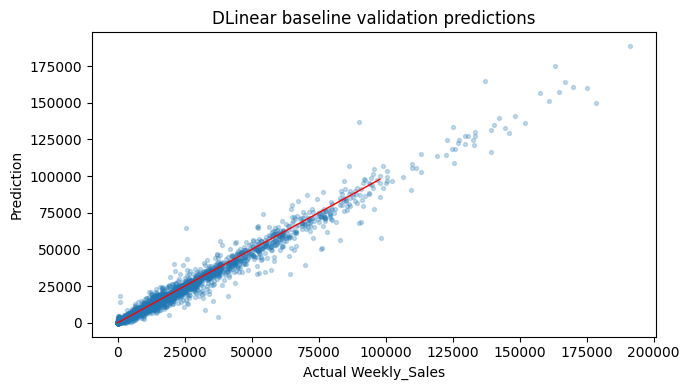

{'best_epoch': 8,
 'best_validation_wmae': 1523.209716796875,
 'seasonal_naive_wmae': 1604.269707356262,
 'improvement_vs_seasonal_naive_pct': 5.0527657654877025,
 'validation_weeks': 39,
 'input_weeks': 52}

In [11]:
series_index = pd.DataFrame(sales_panel.index.tolist(), columns=["Store", "Dept"])
preds = best_val_result["preds"]
targets = best_val_result["targets"]

records = []
for row_idx, (store, dept) in enumerate(sales_panel.index):
    for horizon_idx, date in enumerate(val_dates):
        records.append({
            "Store": int(store),
            "Dept": int(dept),
            "Date": pd.Timestamp(date),
            "IsHoliday": bool(holiday_by_date.loc[date]),
            "Weekly_Sales": float(targets[row_idx, horizon_idx]),
            "Prediction": float(preds[row_idx, horizon_idx]),
            "AbsError": float(abs(targets[row_idx, horizon_idx] - preds[row_idx, horizon_idx])),
        })

val_pred_df = pd.DataFrame(records)
val_pred_path = OUTPUT_DIR / "dlinear_baseline_validation_predictions.csv"
val_pred_df.to_csv(val_pred_path, index=False)

checkpoint = {
    "model_state_dict": model.state_dict(),
    "config": CONFIG,
    "best_epoch": best_epoch,
    "best_validation_wmae": best_val_result["wmae"],
    "series_index": sales_panel.index.tolist(),
    "train_dates": [str(pd.Timestamp(d).date()) for d in all_train_dates],
    "validation_dates": [str(pd.Timestamp(d).date()) for d in val_dates],
}
checkpoint_path = OUTPUT_DIR / "dlinear_baseline_checkpoint.pt"
torch.save(checkpoint, checkpoint_path)

summary_path = OUTPUT_DIR / "dlinear_baseline_summary.json"
summary = {
    "best_epoch": int(best_epoch),
    "best_validation_wmae": float(best_val_result["wmae"]),
    "seasonal_naive_wmae": float(seasonal_naive_wmae),
    "improvement_vs_seasonal_naive_pct": float(100.0 * (seasonal_naive_wmae - best_val_result["wmae"]) / seasonal_naive_wmae),
    "validation_weeks": CONFIG["validation_weeks"],
    "input_weeks": CONFIG["input_weeks"],
}
summary_path.write_text(json.dumps(summary, indent=2))

fig, ax = plt.subplots(figsize=(7, 4))
sample = val_pred_df.sample(min(5000, len(val_pred_df)), random_state=SEED)
ax.scatter(sample["Weekly_Sales"], sample["Prediction"], s=8, alpha=0.25)
max_axis = np.nanpercentile(sample[["Weekly_Sales", "Prediction"]].to_numpy(), 99)
ax.plot([0, max_axis], [0, max_axis], color="red", linewidth=1)
ax.set_title("DLinear baseline validation predictions")
ax.set_xlabel("Actual Weekly_Sales")
ax.set_ylabel("Prediction")
plt.tight_layout()
plot_path = OUTPUT_DIR / "dlinear_validation_scatter.png"
fig.savefig(plot_path, dpi=160)
plt.show()

artifact = wandb.Artifact("dlinear-baseline-39w", type="model")
artifact.add_file(str(checkpoint_path))
artifact.add_file(str(summary_path))
artifact.add_file(str(val_pred_path))
artifact.add_file(str(plot_path))
run.log_artifact(artifact, aliases=["baseline", "latest"])

wandb.log({
    "validation/prediction_table": wandb.Table(dataframe=val_pred_df.sample(min(20000, len(val_pred_df)), random_state=SEED)),
    "validation/scatter": wandb.Image(str(plot_path)),
})

summary

## Optional final refit and submission generation

Keep `run_final_refit=False` for the pure baseline validation run. Turn it on only when you also want a baseline Kaggle submission from the model trained on all available `train.csv` dates.

In [12]:
if CONFIG["run_final_refit"]:
    if len(test_dates) != CONFIG["validation_weeks"]:
        raise ValueError(f"Expected test horizon {CONFIG['validation_weeks']}, got {len(test_dates)}")

    final_train_ds = WindowDataset(
        values=values,
        holiday_flags=holiday_flags,
        input_len=CONFIG["input_weeks"],
        pred_len=CONFIG["validation_weeks"],
        end_pos=len(all_train_dates),
    )
    final_loader = DataLoader(final_train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"], pin_memory=True)
    final_model = DLinear(seq_len=CONFIG["input_weeks"], pred_len=CONFIG["validation_weeks"], moving_avg_kernel=25).to(device)
    final_optimizer = torch.optim.AdamW(final_model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])

    for epoch in range(1, best_epoch + 1):
        final_model.train()
        total_loss = 0.0
        total_weight = 0.0
        for batch in final_loader:
            x = batch["x"].to(device)
            y = batch["y"].to(device)
            weights = batch["weights"].to(device)
            final_optimizer.zero_grad(set_to_none=True)
            pred = final_model(x)
            loss = weighted_mae_loss(pred, y, weights)
            loss.backward()
            if CONFIG["clip_grad_norm"]:
                torch.nn.utils.clip_grad_norm_(final_model.parameters(), CONFIG["clip_grad_norm"])
            final_optimizer.step()
            total_loss += float((torch.abs(pred.detach() - y) * weights).sum().cpu())
            total_weight += float(weights.sum().cpu())
        wandb.log({"final_refit/epoch": epoch, "final_refit/normalized_wmae_loss": total_loss / max(total_weight, 1.0)})

    final_model.eval()
    x_last = values[:, -CONFIG["input_weeks"]:].astype(np.float32)
    means = x_last.mean(axis=1, keepdims=True)
    stds = x_last.std(axis=1, keepdims=True)
    stds = np.maximum(stds, 1.0)
    x_norm = torch.from_numpy(((x_last - means) / stds)[:, :, None]).to(device)
    with torch.no_grad():
        test_pred = final_model(x_norm).cpu().numpy() * stds + means
    test_pred = np.clip(test_pred, 0.0, None)

    pred_lookup = {}
    for row_idx, key in enumerate(sales_panel.index):
        for horizon_idx, date in enumerate(test_dates):
            pred_lookup[(int(key[0]), int(key[1]), pd.Timestamp(date))] = float(test_pred[row_idx, horizon_idx])

    submission = test_raw[["Store", "Dept", "Date"]].copy()
    submission["Weekly_Sales"] = [pred_lookup.get((int(r.Store), int(r.Dept), pd.Timestamp(r.Date)), 0.0) for r in submission.itertuples(index=False)]
    submission.insert(0, "Id", submission["Store"].astype(str) + "_" + submission["Dept"].astype(str) + "_" + submission["Date"].dt.strftime("%Y-%m-%d"))
    submission = submission[["Id", "Weekly_Sales"]]
    submission_path = OUTPUT_DIR / "submission_dlinear_baseline.csv"
    submission.to_csv(submission_path, index=False)

    final_checkpoint_path = OUTPUT_DIR / "dlinear_baseline_final_refit_checkpoint.pt"
    torch.save({"model_state_dict": final_model.state_dict(), "config": CONFIG, "series_index": sales_panel.index.tolist()}, final_checkpoint_path)

    sub_artifact = wandb.Artifact("dlinear-baseline-submission", type="submission")
    sub_artifact.add_file(str(submission_path))
    sub_artifact.add_file(str(final_checkpoint_path))
    run.log_artifact(sub_artifact, aliases=["baseline", "latest"])
    display(submission.head())
else:
    print("Final refit skipped. Set CONFIG['run_final_refit'] = True if you want a baseline submission.")

Final refit skipped. Set CONFIG['run_final_refit'] = True if you want a baseline submission.


In [13]:
run.finish()

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
learning_rate,████████████▃▃▃▃▃▁▁▁
train/normalized_wmae_loss,█▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation/improvement_vs_seasonal_naive_pct,▁▅▅▇▇███▇▇█▇▇█▇██▇██
validation/normalized_wmae_loss,█▃▃▁▁▂▁▂▄▄▃▄▅▄▄▄▄▄▄▄
validation/wmae,█▄▄▂▂▁▁▁▂▂▁▂▂▁▂▁▁▂▁▁
best_epoch,8
best_improvement_vs_seasonal_naive_pct,5.05277
best_validation_wmae,1523.20972
epoch,20
learning_rate,0.00025
